In [1]:
import jax
import jax.numpy as jnp

import equinox as eqx
import equinox.nn as nn
import snnax.snn as snn

import optax

In [2]:
from eleanor.models import Heracles, Scaler, FeLIF
from chex import Array, PRNGKey
from typing import Optional

key = jax.random.key(0)
key1, key2, key3, key4, key5, key6 = jax.random.split(key, 6)


class EncodingLayer(eqx.Module):

    gain: Array
    bias: Array
    expansion: float

    def __init__(self, gain: Array, bias: Array, expansion: float) -> None:
        self.gain = gain
        self.bias = bias
        self.expansion = expansion

    def __call__(self, synaptic_input: Array, *, key: Optional[PRNGKey] = None):
        output = self.gain * (jnp.tile(synaptic_input, self.expansion) + self.bias)
        return output


enc_gain = jax.random.normal(key1, shape=(128,)) * 0.18436009935019085
enc_bias = jax.random.normal(key2, shape=(128,))
model = snn.Sequential(
    EncodingLayer(enc_gain, enc_bias, 32),
    nn.Linear(128, 256, key=key3),
    snn.LIF([0.9, 0.8], key=key4),
    nn.Linear(256, 27, key=key5),
    # snn.LIF([.9, .8], key=key6)
    Scaler(1000, 1),
    FeLIF(dt=1e-3, V_thr=0.3, paramsScale=1e12),
)
model

Sequential(
  graph_structure=GraphStructure(
    num_layers=6,
    input_layer_ids=((0,), (), (), (), (), ()),
    input_connectivity=((), (0,), (1,), (2,), (3,), (4,))
  ),
  layers=[
    EncodingLayer(gain=f32[128], bias=f32[128], expansion=32),
    Linear(
      weight=f32[256,128],
      bias=f32[256],
      in_features=128,
      out_features=256,
      use_bias=True
    ),
    LIF(
      init_fn=<function <lambda>>,
      shape=None,
      decay_constants=f32[2],
      threshold=1.0,
      spike_fn=<function heaviside_with_superspike_surrogate>,
      reset_val=None,
      stop_reset_grad=True
    ),
    Linear(
      weight=f32[27,256],
      bias=f32[27],
      in_features=256,
      out_features=27,
      use_bias=True
    ),
    Scaler(scale=1000, grad_scale=1),
    FeLIF(
      init_fn=<function <lambda>>,
      shape=None,
      A=25.0,
      E_a=0.00127,
      P_s=0.22,
      tau_0=1e-13,
      I_0=0.0001,
      V_t=0.32,
      C_tot=0.5728138392084845,
      alpha=1.3,
 

In [3]:
from functools import partial
from jax.tree_util import tree_map


# Simple batched loss function
@partial(jax.vmap, in_axes=(None, None, 0, 0, 0))
def loss_fn(model, in_states, in_spikes, tgt_class, key):
    out_state, out_spikes = model(in_states, in_spikes, key=key)

    # Get the output of last layer
    final_layer_out = out_spikes[-1][0]
    # final_layer_out = out_spikes[-1]

    # Sum all spikes in each output neuron along time axis
    # pred = tree_map(lambda x: jnp.sum(x, axis=0), final_layer_out)
    pred = final_layer_out.sum(axis=0)

    target = jax.nn.one_hot(tgt_class, 27)
    loss = optax.softmax_cross_entropy(pred, target)
    return loss


# Calculating the gradient with Equinox PyTree filters and
# subsequently jitting the resulting function
@eqx.filter_value_and_grad
def loss_and_grad(model, in_states, in_spikes, tgt_class, key):
    keys = jax.random.split(key, 128)
    return jnp.mean(loss_fn(model, in_states, in_spikes, tgt_class, keys))


@partial(jax.vmap, in_axes=(None, None, 0, 0, 0))
def accuracy_fn(model, in_states, in_spikes, tgt_class, key):
    out_state, out_spikes = model(in_states, in_spikes, key=key)
    final_layer_out = out_spikes[-1][0]
    # final_layer_out = out_spikes[-1]
    pred = final_layer_out.sum(axis=0)
    predicted_class = jnp.argmax(pred)
    return predicted_class == tgt_class


@eqx.filter_jit
def calc_accuracy(model, in_states, in_spikes, tgt_class, key):
    keys = jax.random.split(key, 128)
    accuracy = accuracy_fn(model, in_states, in_spikes, tgt_class, keys)
    return jnp.mean(accuracy)


# Finally, we update the parameters using a simple optimizer
@eqx.filter_jit
def update(model, in_states, opt_state, in_spikes, tgt_class, key):
    # Get gradients
    loss, grads = loss_and_grad(model, in_states, in_spikes, tgt_class, key)

    # Calculate parameter updates using the optimizer
    updates, opt_state = optim.update(grads, opt_state)

    # Update parameter PyTree with Equinox and optax
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

In [1]:
from eleanor.datasets import shuffle, loadBraille

trainset, testset, nb_outputs, nb_channels, nb_steps, time_step = loadBraille(2, 200)
print(nb_channels)
print(nb_steps)
print(time_step)

4
102
0.001


100%|██████████| 150/150 [1:14:17<00:00, 29.72s/it]


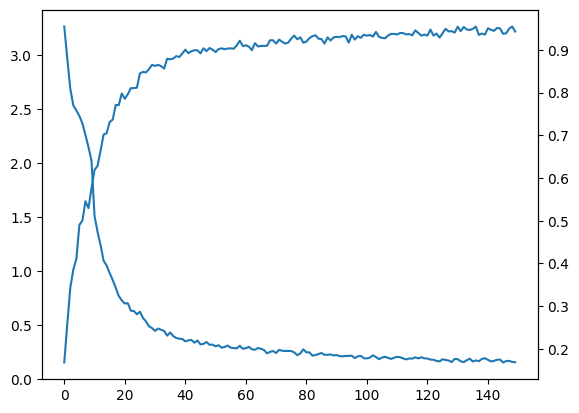

In [5]:
import matplotlib.pyplot as plt
from tqdm import trange

optim = optax.adamax(learning_rate=1e-2, b1=0.9, b2=0.995)
opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))

initial_state = model.init_state(in_shape=(4,), key=jax.random.key(0))
total_loss = []
total_accuracy = []

pbar = trange(0, 150)
for epoch in pbar:
    key, epoch_key = jax.random.split(key)
    x_train, y_train = shuffle(trainset, epoch_key, 128)
    loss_train = []
    for in_spikes, tgt_class in zip(x_train, y_train):
        # Initializing the membrane potentials of LIF neurons
        model, opt_state, loss = update(
            model, initial_state, opt_state, in_spikes, tgt_class, key
        )
        loss_train.append(loss)
    loss_train = jnp.mean(jnp.asarray(loss_train))
    total_loss.append(loss_train)

    x_test, y_test = shuffle(testset, jax.random.key(0), 128)
    accuracy_test = []
    for in_spikes, tgt_class in zip(x_train, y_train):
        # Initializing the membrane potentials of LIF neurons
        accuracy = calc_accuracy(
            model, initial_state, in_spikes, tgt_class, jax.random.key(0)
        )
        accuracy_test.append(accuracy)
    accuracy_test = jnp.mean(jnp.asarray(accuracy_test))
    total_accuracy.append(accuracy_test)


fig, axs = plt.subplots()
axs.plot(total_loss)
axs.twinx().plot(total_accuracy)

plt.show()

In [6]:
jnp.save("results/brailleLossFeLIF_Bruno.npy", total_loss)
jnp.save("results/brailleAccFeLIF_Bruno.npy", total_accuracy)